In [1]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start/plot')
import pandas as pd
import os
from typing import Optional
import numpy as np
import matplotlib.pyplot as plt
from plot.plot_basic import savefig
from plot.plot_1D import plot_multiple_1D_fields
from read_write import read_nc
from plot.plot_2D import plot_multiple_2D_fields,plot_2D_field,plot_polar_field,plot_quiver_field

In [2]:
Nx=100
Ny=80
x_coordinate=np.linspace(0,10,Nx,endpoint=False)
y_coordinate=np.linspace(0,8,Ny,endpoint=False)
X,Y=np.meshgrid(x_coordinate,y_coordinate,indexing='ij')

In [3]:
field_1=np.exp(-((X-3)**2+(Y-4)**2)/2)

In [4]:
dfdx=np.gradient(field_1,x_coordinate,axis=0)
dfdy=np.gradient(field_1,y_coordinate,axis=1)

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)
Auto scale for quiver: 1.500


{'fig': <Figure size 1850x1400 with 6 Axes>,
 'ax_main': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1466bc7f52b0>}

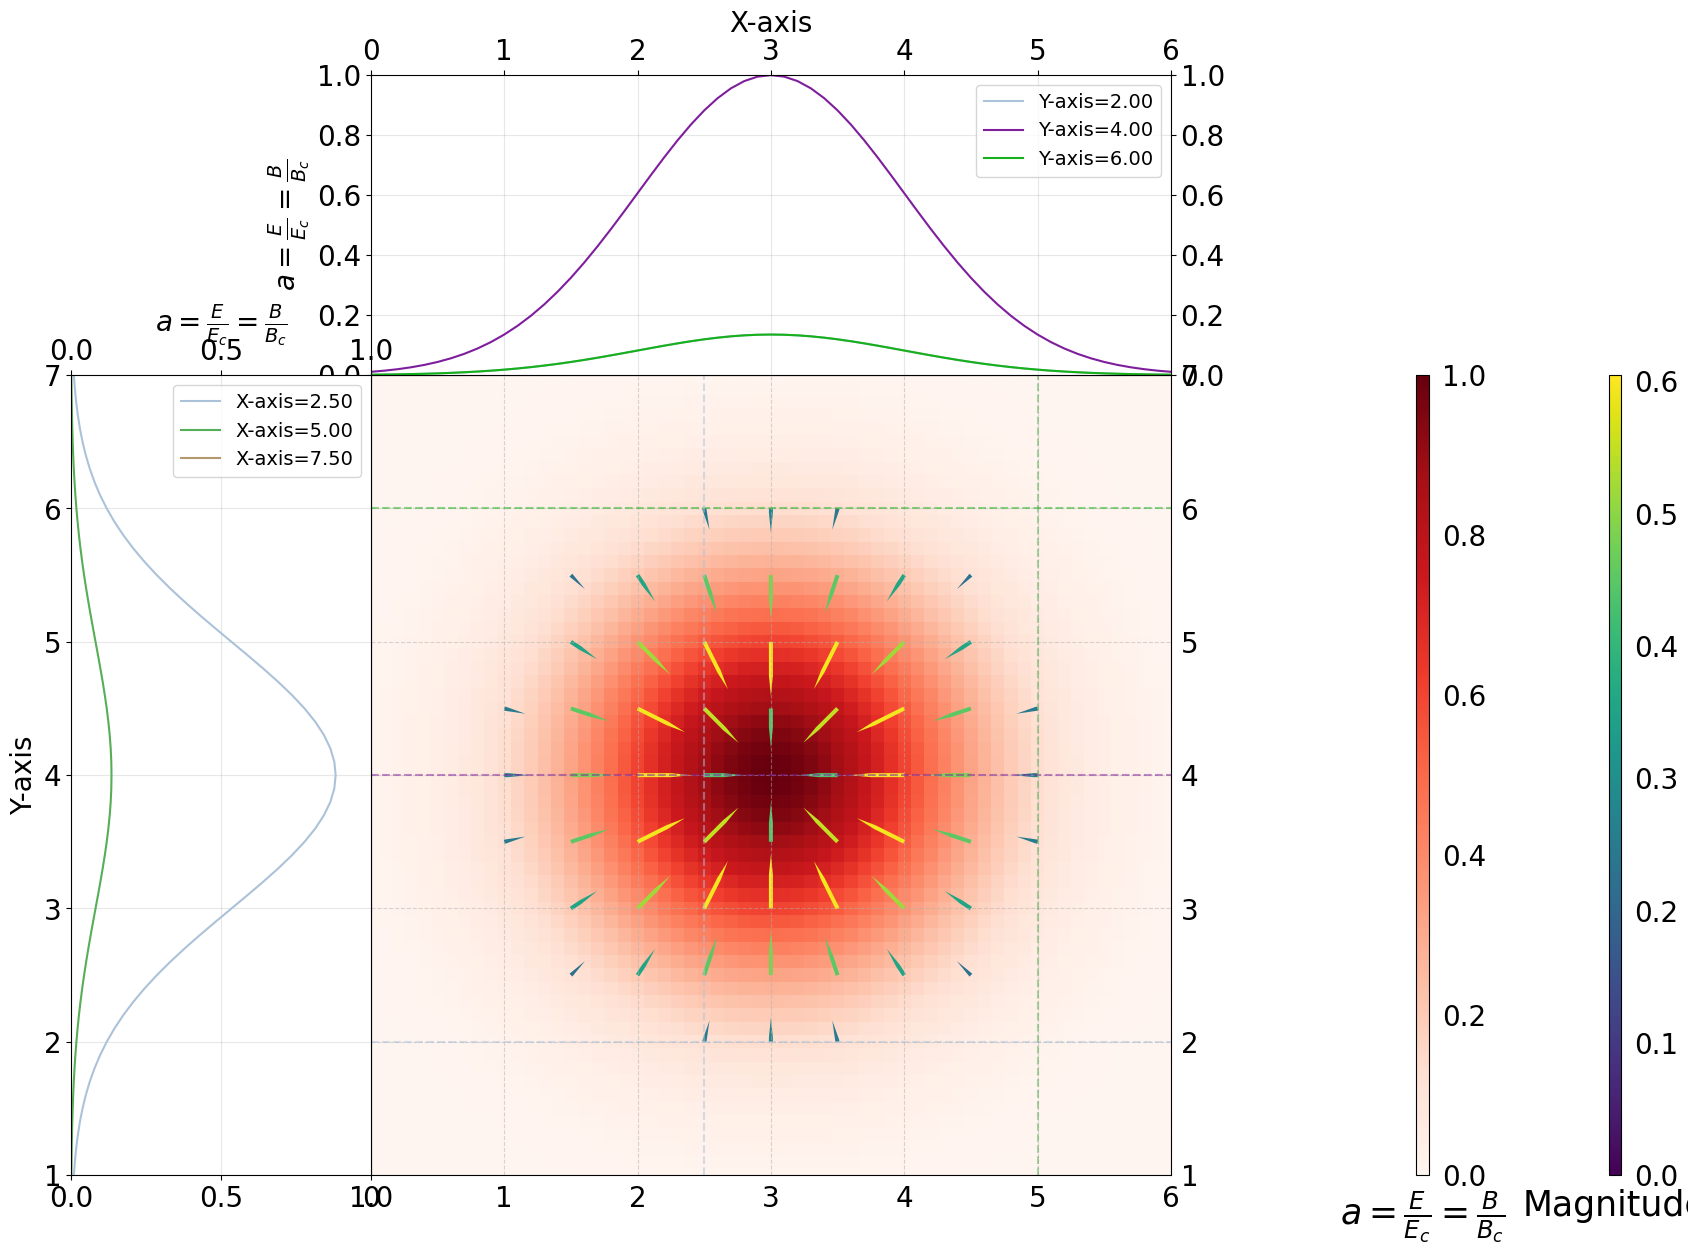

In [5]:
ax_dixt=plot_2D_field(
    field=field_1,
    x_coordinate=x_coordinate,
    y_coordinate=y_coordinate,
    name='Gaussian',
    vmin=0,vmax=1,cmap='Reds',
    xmin=0,xmax=6,ymin=1,ymax=7,aspect=1,
    plot_profile_x=True,profile_at_x=[2.5,5,7.5],ax_profile_x_at='left',
    plot_profile_y=True,profile_at_y=[2,4,6],ax_profile_y_at='top',
    xlabel='X-axis',ylabel='Y-axis',
)
plot_quiver_field(
    x_coordinate=x_coordinate,y_coordinate=y_coordinate,
    Vx=dfdx,Vy=dfdy,
    threshold=0.2,scale=1.5,step_x=5,step_y=5,
    xmin=0,xmax=6,ymin=1,ymax=7,aspect=1,
    ax_dict=ax_dixt
)

/tmp/ipykernel_3218571/3380050421.py:6: RuntimeWarning: divide by zero encountered in divide
  f2=r/np.sin(a)
/tmp/ipykernel_3218571/3380050421.py:6: RuntimeWarning: invalid value encountered in divide
  f2=r/np.sin(a)
/tmp/ipykernel_3218571/3380050421.py:7: RuntimeWarning: invalid value encountered in divide
  field2=f2/(1+f2**2)


figure size= [13.5  9. ] inch
ax_main position= Bbox(x0=0.1111111111111111, y0=0.16666666666666666, x1=0.5555555555555556, y1=0.8333333333333333)


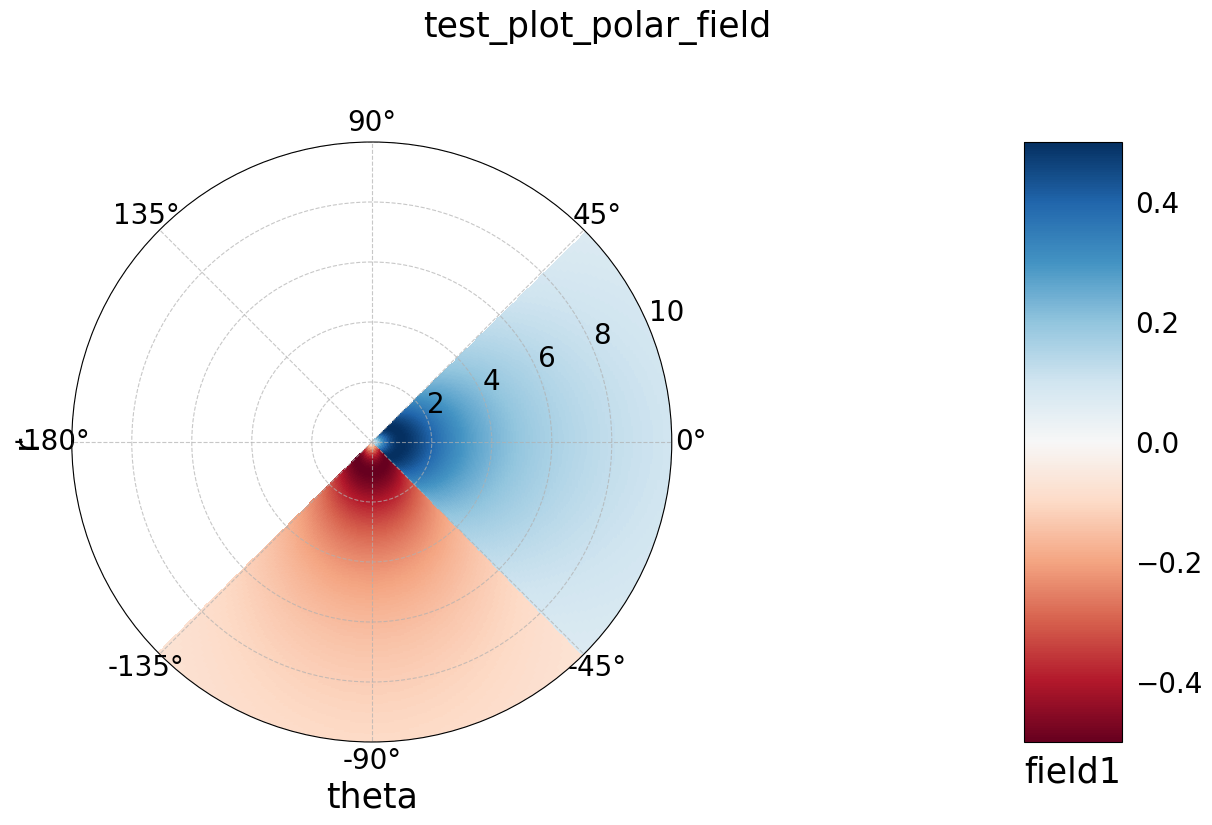

In [6]:
r_coordinate=np.linspace(0,10,201)
a_coordinate=np.linspace(-np.pi,np.pi,361)
a,r=np.meshgrid(a_coordinate,r_coordinate,indexing='ij')
f1=r/np.cos(a)
field1=f1/(1+f1**2)
f2=r/np.sin(a)
field2=f2/(1+f2**2)
ax_dict=plot_polar_field(
    field=field1[135:225,:],
    r_coordinate=r_coordinate,a_coordinate=a_coordinate[135:225],
    r_min=0,r_max=10,
    v_min=-0.5,v_max=0.5,norm=None,
    cmap='RdBu',alpha=1.0,
    label='field1',r_label='r',a_label='theta',
    return_fig=True,name='test_plot_polar_field',working_dir='.',
)

ax_dict=plot_polar_field(
    field=field2[45:135,:],
    r_coordinate=r_coordinate,a_coordinate=a_coordinate[45:135],
    r_min=0,r_max=10,
    v_min=-0.5,v_max=0.5,norm=None,
    cmap='RdBu',alpha=1.0,
    label='field2',r_label='r',a_label='theta',
    ax_dict=ax_dict,
    plot_colorbar=False,
    return_fig=True,name='test_plot_polar_field',working_dir='.',
)
